 SegFormer

Load

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from skimage import io
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt

# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Base Configuration
MY_ROOT_PATH = '/content/drive/MyDrive/Amsterdam'
NEW_DATA_PATH = os.path.join(MY_ROOT_PATH, 'new-data')
os.makedirs(NEW_DATA_PATH, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 4
NUM_CLASSES = 4 # 0: Background, 1: <1981, 2: 1981-2001, 3: >=2001

# 3. Checkpoint & CSV Paths
best_ckpt_path = os.path.join(NEW_DATA_PATH, 'segformer_best.pth')
resume_ckpt_path = os.path.join(NEW_DATA_PATH, 'segformer_resume.pth')
csv_path = os.path.join(NEW_DATA_PATH, 'segmentation_results.csv')

Mounted at /content/drive


Data loader

In [2]:
class AmsterdamDataset(Dataset):
    def __init__(self, base_dir, split='train', transform=None):
        self.image_dir = os.path.join(base_dir, split, 'image')
        self.mask_dir = os.path.join(base_dir, split, 'processed_age')

        # Ensure image and mask filenames match exactly
        img_files = set([f for f in os.listdir(self.image_dir) if f.lower().endswith('.tiff')])
        msk_files = set([f for f in os.listdir(self.mask_dir) if f.lower().endswith('.tiff')])
        self.images = sorted(list(img_files.intersection(msk_files)))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]
        img = io.imread(os.path.join(self.image_dir, name))
        msk = io.imread(os.path.join(self.mask_dir, name))

        if self.transform:
            augmented = self.transform(image=img, mask=msk)
            img, msk = augmented['image'], augmented['mask']
        return img, msk.long()

# Transforms
train_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Create Unified Loaders for all 3 splits
train_loader = DataLoader(AmsterdamDataset(MY_ROOT_PATH, 'train', train_transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AmsterdamDataset(MY_ROOT_PATH, 'val', train_transform), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(AmsterdamDataset(MY_ROOT_PATH, 'test', train_transform), batch_size=BATCH_SIZE, shuffle=False)

print(f"Data Loaded: {len(train_loader)} Train batches, {len(val_loader)} Val batches, {len(test_loader)} Test batches.")

Data Loaded: 175 Train batches, 25 Val batches, 50 Test batches.


Architecture

In [3]:
# 1. Clone the repository
import os
if not os.path.exists('segformer-pytorch'):
    print("Cloning SegFormer repository...")
    !git clone https://github.com/lucidrains/segformer-pytorch.git
else:
    print("Repository already exists.")

# 2. Add to Python path
import sys
if '/content/segformer-pytorch' not in sys.path:
    sys.path.append('/content/segformer-pytorch')

# 3. Import the model
from segformer_pytorch import Segformer

# 4. Initialize Model (Equivalent to B0 configuration)
model = Segformer(
    dims = (32, 64, 160, 256),      # dimensions of each stage
    heads = (1, 2, 5, 8),           # heads of each stage
    ff_expansion = (8, 8, 4, 4),    # feedforward expansion factor of each stage
    reduction_ratio = (8, 4, 2, 1), # reduction ratio of each stage for efficient attention
    num_layers = (2, 2, 2, 2),      # num layers of each stage
    decoder_dim = 256,              # decoder dimension
    num_classes = NUM_CLASSES
).to(DEVICE)

# 5. Loss and Optimizer
# Transformers are sensitive; we use the successful weights but a slightly
# different learning rate strategy common for attention-based models.
class_weights = torch.tensor([0.5, 5.0, 10.0, 10.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW is mandatory for Transformers.
# We use a slightly lower learning rate (6e-5) which is standard for SegFormer.
import torch.optim as optim
optimizer = optim.AdamW(model.parameters(), lr=0.00006, weight_decay=0.01)

print("✅ SegFormer (MiT-B0) initialized successfully.")

Cloning SegFormer repository...
Cloning into 'segformer-pytorch'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (40/40), done.
Receiving objects: 100% (56/56), 103.35 KiB | 6.46 MiB/s, done.
remote: Total 56 (delta 26), reused 35 (delta 14), pack-reused 0 (from 0)
Resolving deltas: 100% (26/26), done.
✅ SegFormer (MiT-B0) initialized successfully.


Train

In [ ]:
import os
import gc
import torch
from tqdm import tqdm

epochs = 40
start_epoch = 0
best_val_loss = float('inf')

# 1. UPDATED: New PyTorch 2.x syntax for the GradScaler
scaler = torch.amp.GradScaler('cuda')

if os.path.exists(resume_ckpt_path):
    print(f"Loading checkpoint from {resume_ckpt_path}...")
    checkpoint = torch.load(resume_ckpt_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_loss = checkpoint['best_val_loss']
    print(f"Resuming training from Epoch {start_epoch + 1}.")

for epoch in range(start_epoch, epochs):
    # --- TRAINING ---
    model.train()
    epoch_train_loss = 0
    with tqdm(total=len(train_loader), desc=f'Epoch {epoch + 1}/{epochs} [Train]', unit='batch') as pbar:
        for imgs, msks in train_loader:
            imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

            optimizer.zero_grad()

            # 2. UPDATED: New syntax for Autocast
            with torch.amp.autocast('cuda'):
                masks_pred = model(imgs)
                masks_pred = F.interpolate(masks_pred, size=msks.shape[1:], mode='bilinear', align_corners=False)
                loss = criterion(masks_pred, msks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_train_loss += loss.item()
            pbar.set_postfix(**{'loss': loss.item()})
            pbar.update(1)

    avg_train_loss = epoch_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

            # 3. UPDATED: New syntax for Autocast
            with torch.amp.autocast('cuda'):
                outputs = model(imgs)
                outputs = F.interpolate(outputs, size=msks.shape[1:], mode='bilinear', align_corners=False)
                loss = criterion(outputs, msks)

            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    print(f"End of Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- SAVE CHECKPOINTS ---
    if avg_val_loss < best_val_loss:
        print(f"🟢 Val Loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving best model.")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_ckpt_path)

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss
    }, resume_ckpt_path)

    # --- MEMORY CLEANUP ---
    torch.cuda.empty_cache()
    gc.collect()

Epoch 1/40 [Train]: 100%|██████████| 175/175 [09:17<00:00,  3.19s/batch, loss=1.36]


End of Epoch 1 | Train Loss: 1.2816 | Val Loss: 1.2736
🟢 Val Loss improved from inf to 1.2736. Saving best model.


Epoch 2/40 [Train]: 100%|██████████| 175/175 [00:28<00:00,  6.09batch/s, loss=0.974]


End of Epoch 2 | Train Loss: 1.1863 | Val Loss: 1.1658
🟢 Val Loss improved from 1.2736 to 1.1658. Saving best model.


Epoch 3/40 [Train]: 100%|██████████| 175/175 [00:31<00:00,  5.56batch/s, loss=1.19]


...

End of Epoch 38 | Train Loss: 0.3911 | Val Loss: 1.8677


Epoch 39/40 [Train]: 100%|██████████| 175/175 [00:31<00:00,  5.51batch/s, loss=0.548]


End of Epoch 39 | Train Loss: 0.3720 | Val Loss: 1.7982


Epoch 40/40 [Train]: 100%|██████████| 175/175 [00:31<00:00,  5.60batch/s, loss=0.643]


End of Epoch 40 | Train Loss: 0.3608 | Val Loss: 1.9376


Test

In [ ]:
def get_confusion_matrix(preds, labels, num_classes):
    """Returns a confusion matrix for the batch."""
    mask = (labels >= 0) & (labels < num_classes)
    hist = torch.bincount(
        num_classes * labels[mask].astype(int) + preds[mask],
        minlength=num_classes**2
    ).reshape(num_classes, num_classes)
    return hist

# 1. Initialize Global Confusion Matrix
model.load_state_dict(torch.load(best_ckpt_path))
model.eval()

# We use a numpy array to store the sum of all batch confusion matrices
total_conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))

print("Starting global test evaluation...")

with torch.no_grad():
    for imgs, msks in tqdm(test_loader, desc="Testing"):
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            outputs = F.interpolate(outputs, size=msks.shape[1:], mode='bilinear', align_corners=False)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = msks.cpu().numpy()

        # Accumulate the confusion matrix
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                total_conf_matrix[i, j] += np.sum((labels == i) & (preds == j))

# 2. Calculate Final Metrics from the Global Matrix
tp = np.diag(total_conf_matrix)
fp = np.sum(total_conf_matrix, axis=0) - tp
fn = np.sum(total_conf_matrix, axis=1) - tp

# Calculate IoU for each class
# We add a tiny epsilon (1e-6) to avoid division by zero
ious = tp / (tp + fp + fn + 1e-6)
final_miou = np.mean(ious)
final_acc = np.sum(tp) / np.sum(total_conf_matrix)

print(f"\n--- Final Results ---\nmIoU: {final_miou:.4f} | Accuracy: {final_acc:.4f}")

# 3. Create the CSV Entry
model_name = "SegFormer_B0"  # Update this for each model
results_dict = {
    'Model': model_name,
    'mIoU': final_miou,
    'Overall_Acc': final_acc,
    'IoU_Background': ious[0],
    'IoU_<1981': ious[1],
    'IoU_1981-2001': ious[2],
    'IoU_>=2001': ious[3]
}

# (The rest of your CSV saving logic is perfect and doesn't need to change)
new_df = pd.DataFrame([results_dict])
if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    final_df = pd.concat([existing_df, new_df], ignore_index=True).drop_duplicates(subset=['Model'], keep='last')
else:
    final_df = new_df

final_df.to_csv(csv_path, index=False)

Starting global test evaluation...


Testing: 100%|██████████| 50/50 [01:25<00:00,  1.71s/it]



--- Final Results ---
mIoU: 0.3029 | Accuracy: 0.6854


Scanning validation set for a dense neighborhood...
Requirement: At least 2500 pixels for EACH of the 3 building ages.
✅ PERFECT PATCH FOUND!
   Pixels -> <1981: 6303 | 1981-2001: 122228 | >=2001: 3575


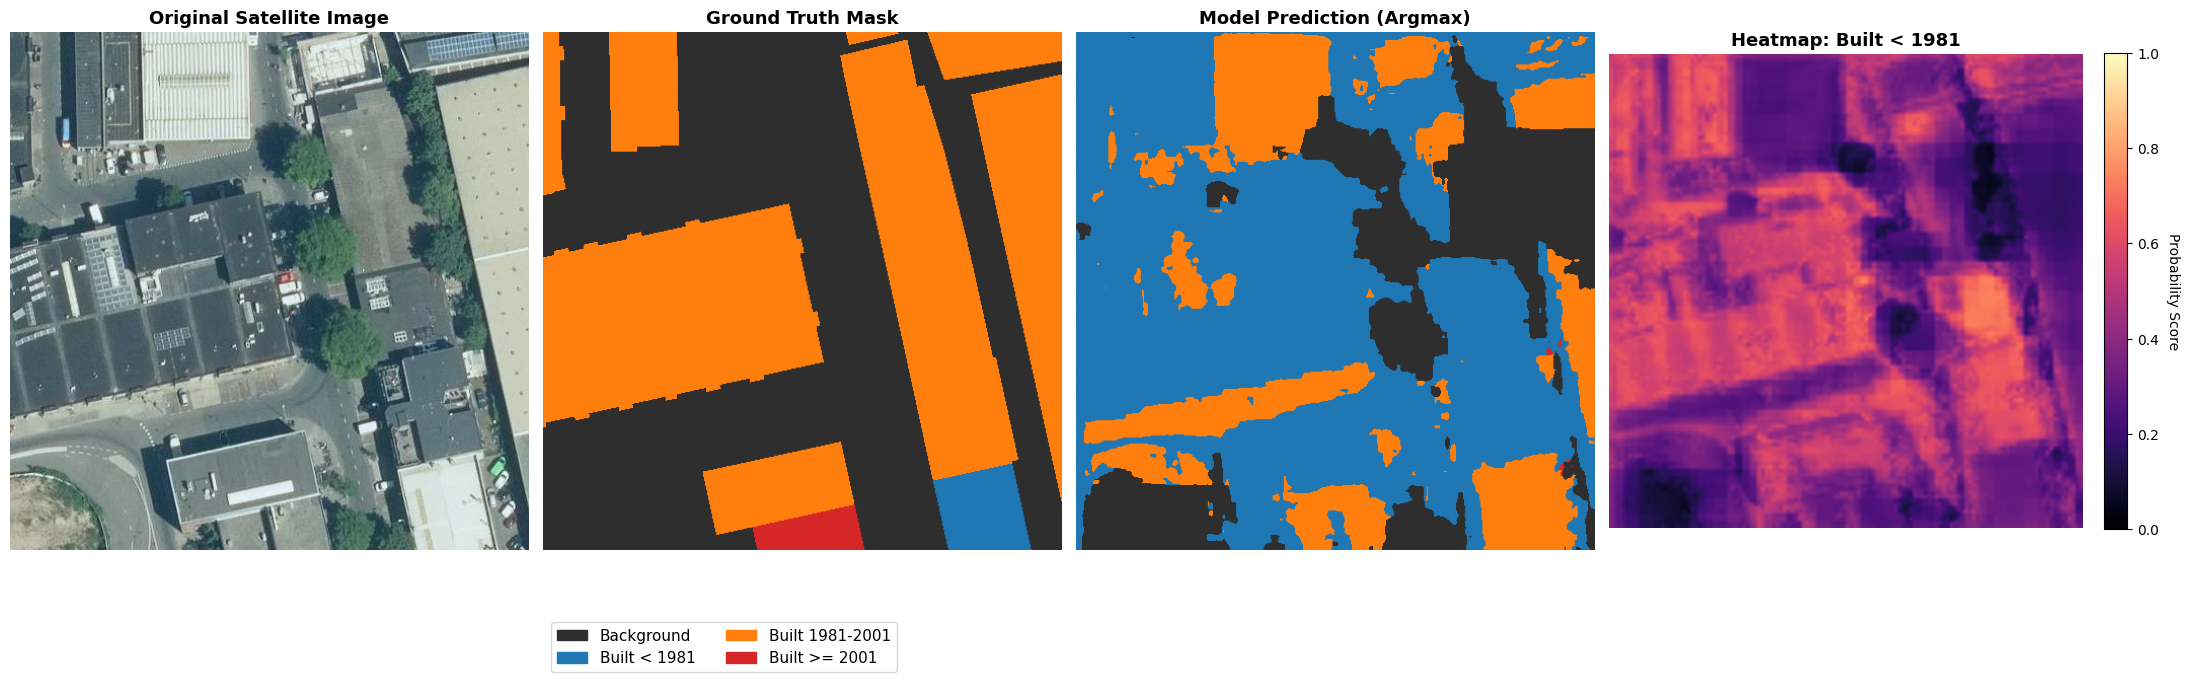

In [4]:
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import ListedColormap


model.load_state_dict(torch.load(best_ckpt_path))

def visualize_model_prediction_with_legend(model, loader, device, class_to_view=1, min_pixels=500):
    model.eval()

    print(f"Scanning validation set for a dense neighborhood...")
    print(f"Requirement: At least {min_pixels} pixels for EACH of the 3 building ages.")

    best_imgs, best_msks = None, None
    max_valid_classes = 0
    best_total_pixels = 0

    with torch.no_grad():
        # --- THE STRICT SCANNER ---
        for imgs, msks in loader:
            mask_0 = msks[0]

            # Count the exact number of pixels for each building class
            count_1 = (mask_0 == 1).sum().item()
            count_2 = (mask_0 == 2).sum().item()
            count_3 = (mask_0 == 3).sum().item()

            # Check how many classes meet your strict pixel requirement
            valid_classes = sum(1 for c in [count_1, count_2, count_3] if c >= min_pixels)
            total_buildings = count_1 + count_2 + count_3

            # If we find a patch where ALL 3 classes have enough pixels, stop instantly!
            if valid_classes == 3:
                print(f"✅ PERFECT PATCH FOUND!")
                print(f"   Pixels -> <1981: {count_1} | 1981-2001: {count_2} | >=2001: {count_3}")
                best_imgs, best_msks = imgs, msks
                max_valid_classes = 3
                break

            # FALLBACK: If we haven't found a perfect one, keep track of the best one so far
            if valid_classes >= max_valid_classes:
                if valid_classes > max_valid_classes or total_buildings > best_total_pixels:
                    max_valid_classes = valid_classes
                    best_total_pixels = total_buildings
                    best_imgs, best_msks = imgs, msks

        if max_valid_classes < 3:
            print(f"⚠️ Could not find a patch where all 3 classes met the {min_pixels} pixel limit.")
            print(f"   Using the best fallback patch (contains {max_valid_classes} classes above threshold).")

        # Load the winning patch onto the GPU
        imgs, msks = best_imgs.to(device), best_msks.to(device)

        # --- RUN INFERENCE ---
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            # Upsample fix for SegFormer/HRNet
            if outputs.shape[2:] != msks.shape[1:]:
                outputs = F.interpolate(outputs, size=msks.shape[1:], mode='bilinear', align_corners=False)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

    # --- PLOTTING ---
    img_idx = 0
    plt.figure(figsize=(22, 6))

    # --- 1. Original Satellite Image ---
    plt.subplot(1, 4, 1)
    img_show = imgs[img_idx].permute(1, 2, 0).cpu().numpy()
    img_min, img_max = img_show.min(), img_show.max()
    img_show = (img_show - img_min) / (img_max - img_min + 1e-8)
    if img_show.shape[-1] > 3:
        img_show = img_show[:, :, :3]
    plt.imshow(img_show)
    plt.title("Original Satellite Image", fontsize=13, fontweight='bold')
    plt.axis('off')

    # --- Define Colors and Labels ---
    color_list = ['#2E2E2E', '#1f77b4', '#ff7f0e', '#d62728']
    class_names = ['Background', 'Built < 1981', 'Built 1981-2001', 'Built >= 2001']
    class_cmap = ListedColormap(color_list)
    legend_patches = [mpatches.Patch(color=color_list[i], label=class_names[i]) for i in range(len(class_names))]

    # --- 2. Ground Truth ---
    plt.subplot(1, 4, 2)
    plt.imshow(msks[img_idx].cpu().numpy(), cmap=class_cmap, vmin=0, vmax=3)
    plt.title("Ground Truth Mask", fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.legend(handles=legend_patches, loc='lower left', bbox_to_anchor=(0.0, -0.25), ncol=2, fontsize=11)

    # --- 3. Model Prediction ---
    plt.subplot(1, 4, 3)
    plt.imshow(preds[img_idx].cpu().numpy(), cmap=class_cmap, vmin=0, vmax=3)
    plt.title("Model Prediction (Argmax)", fontsize=13, fontweight='bold')
    plt.axis('off')

    # --- 4. Confidence Heatmap ---
    plt.subplot(1, 4, 4)
    confidence_map = probs[img_idx, class_to_view].cpu().numpy()
    im = plt.imshow(confidence_map, cmap='magma', vmin=0, vmax=1.0)
    plt.colorbar(im, fraction=0.046, pad=0.04).set_label('Probability Score', rotation=270, labelpad=15)
    plt.title(f"Heatmap: {class_names[class_to_view]}", fontsize=13, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run it with the strict limit (adjust min_pixels up or down if needed!)
visualize_model_prediction_with_legend(model, val_loader, DEVICE, class_to_view=1, min_pixels=2500)